In [1]:
!unzip -q ./damage.zip

unzip:  cannot find or open ./damage.zip, ./damage.zip.zip or ./damage.zip.ZIP.


In [ ]:
!pip install -q ultralytics opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.1 MB/s eta 0:00:00


In [ ]:
import os
import random
import shutil
import cv2
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import ultralytics
from tqdm import tqdm
from pycocotools import mask as maskUtils

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
train_root = f'./train'
valid_root = f'./valid'
test_root = f'./test'
cls_list = ['Scratched', 'Crushed', 'Breakage', 'Separated']

In [ ]:
for folder in [train_root, valid_root, test_root]:
    if not os.path.exists(folder):
        os.makedirs(folder)
    for s in ['images', 'labels']:
        s_folder = f'{folder}/{s}'
        if not os.path.exists(s_folder):
            os.makedirs(s_folder)

In [ ]:
data_list = glob.glob('/content/원천데이터/TS_damage/damage/*.jpg')
len(data_list)

1200

In [ ]:
data_list[0]

'/content/원천데이터/TS_damage/damage/0359094_sc-206072.jpg'

In [ ]:
def draw_polygon_by_index(idx):
    image_path = data_list[idx]
    image = cv2.imread(image_path)
    json_path = image_path.replace('원천데이터', '라벨링데이터').replace('TS_damage', 'TL_damage').replace('.jpg', '.json')
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    with open(json_path, 'r') as f:
        data = json.load(f)

    for ann in data['annotations']:
        if 'segmentation' in ann:
            segmentation = ann['segmentation']
            if isinstance(segmentation, list):  # segmentation 좌표를 폴리라인(다각형 외곽선)으로 그리는 부분
                for seg in segmentation:
                    if isinstance(seg, list):
                        points = np.array(seg).reshape(-1, 2).astype(np.int32)
                        cv2.polylines(image, [points], isClosed = True, color = (255, 0, 0), thickness=2)

    plt.figure(figsize=(10, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Polygon Overlay: {os.path.basename(image_path)}')
    plt.show()

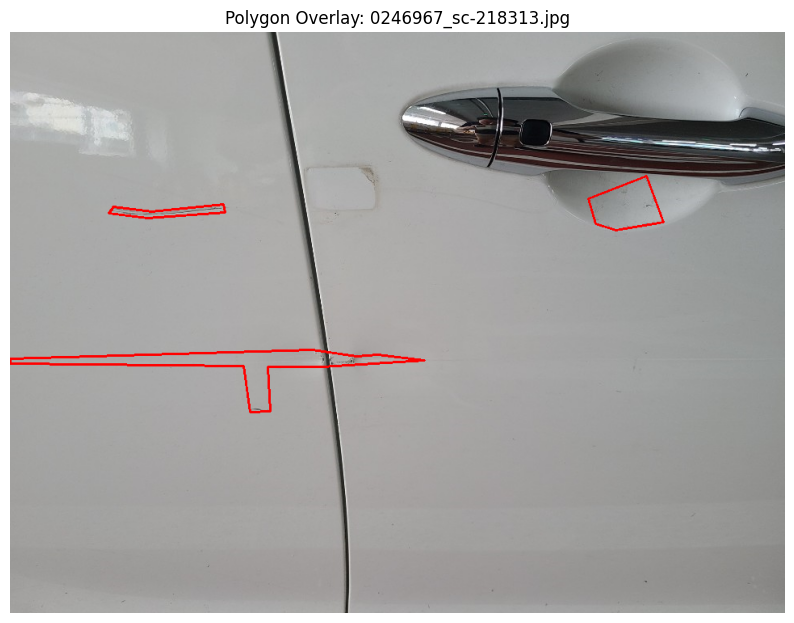

In [ ]:
draw_polygon_by_index(15)

In [ ]:
damage_classes = {
    "Scratched": 0,
    "Crushed": 1,
    "Breakage": 2,
    "Separated": 3
}

In [ ]:
def convert_json_to_yolo(json_path, save_dir):
    with open(json_path, 'r') as f:
        data = json.load(f)

    image_info = data['images']
    img_width, img_height = image_info['width'], image_info['height']

    yolo_annotations = []

    for ann in data['annotations']:
        if 'segmentation' in ann and 'damage' in ann:
            segmentation = ann['segmentation'][0][0]

            if isinstance(segmentation[0], list):
                segmentation = [coord for sublist in segmentation for coord in sublist]

            normalized_coords = [segmentation[i] / img_width if i % 2 == 0 else segmentation[i] / img_height for i in range(len(segmentation))]  # 폴리곤 꼭짓점 좌표를 정규화

            class_label = damage_classes.get(ann['damage'], -1)
            yolo_annotations.append(f'{class_label} ' + ' '.join(map(str, normalized_coords)))  # 좌표 쓸 때마다 한칸씩 띄어주기

    yolo_filename = os.path.basename(json_path).replace('.json', '.txt')
    save_path = os.path.join(save_dir, yolo_filename)

    with open(save_path, 'w') as f:
        f.write('\n'.join(yolo_annotations))

In [ ]:
for json_path in tqdm(glob.glob(os.path.join('/content/라벨링데이터/TL_damage/damage', '*.json'))):
    if not os.path.exists('./labels'):
        os.makedirs('./labels')
    convert_json_to_yolo(json_path, './labels')
print('YOLO 형식 변환 완료!')

100%|██████████| 1200/1200 [00:00<00:00, 3313.43it/s]

YOLO 형식 변환 완료!


In [ ]:
random.seed(2025)
file_list = glob.glob('./labels/*.txt')

random.shuffle(file_list)
test_ratio = 0.1  # 전체 데이터 중 10%를 테스트 세트로 쓰겠다
num_file = len(file_list)
num_file

1200

In [ ]:
test_list = file_list[:int(num_file*test_ratio)]
valid_list = file_list[int(num_file*test_ratio):int(num_file*test_ratio)*2]
train_list = file_list[int(num_file*test_ratio)*2:]

len(train_list), len(valid_list), len(test_list)

(960, 120, 120)

In [ ]:
# ./labels/0051632_sc-164684.txt
test_list

['./labels/0296182_sc-227015.txt',
 './labels/0272786_sc-108145.txt',
 './labels/0455456_sc-179835.txt',
 './labels/0292789_sc-139597.txt',
 './labels/0011570_as-7872658.txt',
 './labels/0238908_sc-159047.txt',
 './labels/0405046_as-0094498.txt',
 './labels/0188888_as-0099755.txt',
 './labels/0167936_sc-197322.txt',
 './labels/0501846_sc-160131.txt',
 './labels/0484948_sc-132079.txt',
 './labels/0192738_sc-168325.txt',
 './labels/0015745_sc-220289.txt',
 './labels/0116621_as-0099662.txt',
 './labels/0228613_as-0062902.txt',
 './labels/0366849_sc-144758.txt',
 './labels/0148526_sc-127733.txt',
 './labels/0271398_sc-228837.txt',
 './labels/0206562_as-7584702.txt',
 './labels/0251758_as-0099709.txt',
 './labels/0058678_as-3125632.txt',
 './labels/0163386_sc-124959.txt',
 './labels/0426481_sc-145224.txt',
 './labels/0198698_sc-136643.txt',
 './labels/0435738_sc-218161.txt',
 './labels/0464106_as-3031666.txt',
 './labels/0432998_sc-133026.txt',
 './labels/0035820_as-2937017.txt',
 './labels

In [ ]:
for i in tqdm(test_list):
    label_name = i.split('/')[-1]
    shutil.copyfile(i, f'{test_root}/labels/{label_name}')  # 파일이름을 복사해서 test_root/labels/0051632_sc-164684.txt로 저장.
    img_name = i.split('/')[-1].replace('.txt', '.jpg')
    img_path = f'/content/원천데이터/TS_damage/damage/{img_name}'  # 원본 이미지가 저장된 폴더 경로 생성.
    shutil.copyfile(img_path, f'{test_root}/images/{img_name}')  # 원본 이미지를 테스트 세트 images 폴더로 복사.
    # 이렇게 하면 labels와 images 폴더가 같은 파일 이름을 가지게 되어 YOLO 학습 형식에 맞게 됨.

100%|██████████| 120/120 [00:00<00:00, 1688.84it/s]


**흐름 정리**

이 코드는 라벨 파일과 대응되는 이미지 파일을 찾아서, 테스트 세트 폴더로 옮기는 역할을 한다.

1. 라벨 파일(.txt) 경로 읽기
2. 테스트 세트 labels 폴더에 복사
3. 같은 이름의 .jpg 이미지 찾기
4. 테스트 세트 images 폴더에 복사

In [ ]:
for i in tqdm(valid_list):
    label_name = i.split('/')[-1]
    shutil.copyfile(i, f'{valid_root}/labels/{label_name}')
    img_name = i.split('/')[-1].replace('txt', 'jpg')
    img_path = f'/content/원천데이터/TS_damage/damage/{img_name}'
    shutil.copyfile(img_path, f'{valid_root}/images/{img_name}')

100%|██████████| 120/120 [00:00<00:00, 1084.03it/s]


In [ ]:
for i in tqdm(train_list):
    label_name = i.split('/')[-1]
    shutil.copyfile(i, f'{train_root}/labels/{label_name}')
    img_name = i.split('/')[-1].replace('txt', 'jpg')
    img_path = f'/content/원천데이터/TS_damage/damage/{img_name}'
    shutil.copyfile(img_path, f'{train_root}/images/{img_name}')

100%|██████████| 960/960 [00:03<00:00, 277.74it/s]


In [ ]:
import yaml

data = dict()

data['train'] = train_root
data['val'] = valid_root
data['test'] = test_root
data['nc'] = len(cls_list)
data['names'] = cls_list

with open(f'car_damage.yaml', 'w') as f:
    yaml.dump(data, f)

In [ ]:
from ultralytics import YOLO

# 모델, 네트워크 구조와 하이퍼파라미터를 정의한 YAML파일
model = YOLO('yolov8s-seg.yaml')
results = model.train(
    data = 'car_damage.yaml',
    epochs = 30,
    imgsz = 224,
    batch = 16,
    device = 0,
    name = 'damage_s'
)

Ultralytics 8.3.177 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=car_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=damage_s8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True,

Overriding model.yaml nc=80 with nc=4

                   from  n    params  module                                       arguments                     
  0                  -1  1       928  ultralytics.nn.modules.conv.Conv             [3, 32, 3, 2]                 
  1                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  2                  -1  1     29056  ultralytics.nn.modules.block.C2f             [64, 64, 1, True]             
  3                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  4                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  5                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128, 256, 3, 2]              
  6                  -1  2    788480  ultralytics.nn.modules.block.C2f             [256, 256, 2, True]           
  7                  -1  1   1180672  ultralytics

YOLOv8s-seg summary: 151 layers, 11,791,644 parameters, 11,791,628 gradients, 42.7 GFLOPs

Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2217.4±1341.9 MB/s, size: 540.2 KB)


train: Scanning /content/train/labels... 960 images, 0 backgrounds, 0 corrupt: 100%|██████████| 960/960 [00:00<00:00, 1267.18it/s]

...

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95):  50%|█████     | 2/4 [00:00<00:01,  1.90it/s]

WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image for speed...
WARNING ⚠️ Limiting validation plots to first 50 items per image

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.65it/s]


                   all        120        327      0.318     0.0317      0.032     0.0134      0.263     0.0109    0.00842    0.00183
             Scratched         99        222     0.0962      0.018      0.013    0.00476          0          0   0.000993   0.000205
               Crushed         15         17          1          0    0.00595    0.00283          1          0    0.00199   0.000363
              Breakage         37         46      0.178      0.109     0.0828     0.0302     0.0518     0.0435    0.00777    0.00217
             Separated         31         42          0          0     0.0263     0.0157          0          0     0.0229    0.00456
Speed: 0.2ms preprocess, 2.1ms inference, 0.0ms loss, 6.6ms postprocess per image
Results saved to runs/segment/damage_s8


----------------------------------------------

```
if isinstance(segmentation, list):  
    # segmentation이 리스트(다각형 좌표들의 집합)인지 확인
    
    for seg in segmentation:  
        # segmentation 안에 있는 각 다각형(seg)을 순회
        
        if isinstance(seg, list):  
            # 각 seg도 좌표 리스트인지 확인
            
            points = np.array(seg).reshape(-1, 2).astype(np.int32)  
            # 좌표를 numpy 배열로 변환하고 (x, y) 형태로 재배열
            # int32로 변환 → OpenCV는 int32 정수 좌표를 요구함
            
            cv2.polylines(image, [points], isClosed=True, color=(255, 0, 0), thickness=2)  
            # 이미지에 다각형 윤곽선을 그림
            # isClosed=True → 마지막 점과 첫 점을 연결해 닫힌 다각형으로 만듦
            # color=(255,0,0) → BGR 순서로 파란색
            # thickness=2 → 선 두께

```

**convert_json_to_yolo**
```
for ann in data['annotations']:
    if 'segmentation' in ann and 'damage' in ann:
        segmentation = ann['segmentation'][0][0]
for ann in data['annotations']:


→ annotations 배열에서 한 객체(annotation)씩 꺼내옴.

if 'segmentation' in ann
→ 해당 annotation에 segmentation 키가 있으면 통과.

and 'damage' in ann
→ 여기서 'damage'는 키(key) 검사입니다.
즉, ann 딕셔너리에 'damage'라는 key가 있어야 True.

segmentation = ann['segmentation'][0][0]
→ segmentation 구조에서 첫 번째 다각형 안의 첫 번째 좌표 묶음을 꺼냅니다.
결과: [[3, 360], [342, 374], ...]
```


```
 if isinstance(segmentation[0], list):
                segmentation = [coord for sublist in segmentation for coord in sublist]


for sublist in segmentation:    # sublist = [3, 360], [342, 374], ...
    for coord in sublist:       # coord = 3, 360, 342, 374, ...
        flat.append(coord)
segmentation = flat

예시 결과: [3, 360, 342, 374, 548, 379]

```

```
normalized_coords = [
    segmentation[i] / img_width if i % 2 == 0 else segmentation[i] / img_height
    for i in range(len(segmentation))
]

>> segmentation 리스트의 각 좌표값을 이미지 크기로 나누어 0~1 범위로 정규화한다.
짝수 인덱스(i % 2 == 0)는 x좌표 → img_width로 나누고,
홀수 인덱스(i % 2 != 0)는 y좌표 → img_height로 나눈다.
```

나누는 이유: YOLO형식은 픽셀 단위 좌표 대신, 이미지 너비와 높이를 기준으로 비율(0~1)로 변환한 좌표를 쓴다.

예:
- 원래 좌표: (300, 150)
- 이미지 크기: width = 600, height = 300
- 정규화:
    - x: 300 / 600 = 0.5
    - y: 150 / 300 = 0.5
- 결과: (0.5, 0.5)

segmentation = [300, 150, 450, 200]
img_width = 600
img_height = 300
```
normalized_coords = [
    segmentation[i] / img_width if i % 2 == 0 else segmentation[i] / img_height
    for i in range(len(segmentation))
]
# 결과: [0.5, 0.5, 0.75, 0.666666...]
```